Dataset loaded successfully!
Shape: (50000, 31)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.39,6.84,...,1,0,62.3,6.57,40.6,65.7,No,Medium,0,0
1,2,Male,Chennai,Tier2,ECE,AI,Yes,No,5.95,6.74,...,2,0,44.0,5.86,40.3,51.8,No,Medium,0,0
2,3,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.13,8.11,...,2,1,73.8,7.50,73.6,67.9,No,High,1,0
3,4,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.37,9.97,...,6,2,100.0,9.41,98.7,NaN,No,Excellent,1,0
4,5,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,8.25,8.99,...,4,2,90.8,9.24,83.1,100.0,No,Excellent,1,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Specialisation      50000 non-null  object 
 6   Hostel              50000 non-null  object 
 7   HistoryOfBacklogs   50000 non-null  object 
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-n

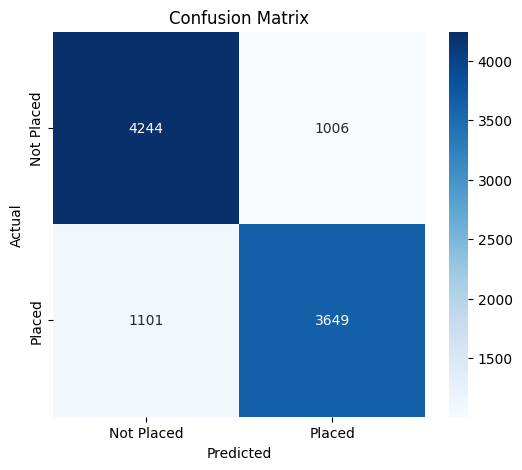

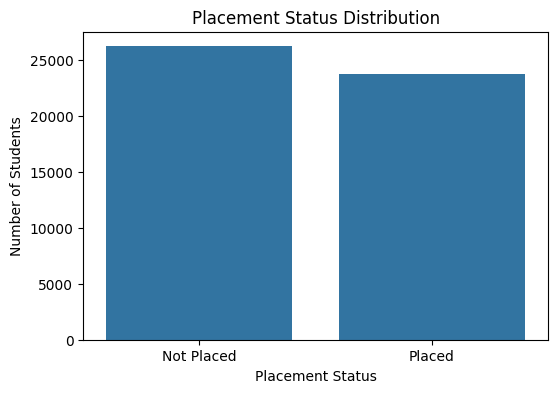


NEW STUDENT PREDICTION
Prediction: PLACED
Probability of Placement: 95.5 %
Probability of Not Placement: 4.5 %


In [1]:
# ============================================================
# PLACEMENT PREDICTION - MACHINE LEARNING PROJECT
# Dataset: placement_predict_50k.csv
# ============================================================

# STEP 1: Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# STEP 2: Load dataset
# ============================================================

# If the file is already uploaded to Colab:
df = pd.read_csv('/content/placement_predict_50k.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())


# ============================================================
# STEP 3: Basic dataset information
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ============================================================
# STEP 4: Remove unnecessary columns
# ============================================================

# StudentID is only an identifier.
# IsAnomaly is not used because it is not the target.

df = df.drop(columns=['StudentID', 'IsAnomaly'], errors='ignore')


# ============================================================
# STEP 5: Define input features and target
# ============================================================

X = df.drop('PlacementStatus', axis=1)
y = df['PlacementStatus']

print("\nFeatures:", X.shape)
print("Target:", y.shape)

print("\nPlacement Distribution:")
print(y.value_counts())


# ============================================================
# STEP 6: Identify numerical and categorical columns
# ============================================================

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# STEP 7: Preprocessing
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)


# ============================================================
# STEP 8: Create Machine Learning Model
# ============================================================

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# STEP 9: Create Pipeline
# ============================================================

pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', model)
    ]
)


# ============================================================
# STEP 10: Split dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# STEP 11: Train model
# ============================================================

print("\nTraining Random Forest model...")

pipeline.fit(X_train, y_train)

print("Model training completed!")


# ============================================================
# STEP 12: Make predictions
# ============================================================

y_pred = pipeline.predict(X_test)


# ============================================================
# STEP 13: Calculate accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print("Accuracy:", round(accuracy * 100, 2), "%")


# ============================================================
# STEP 14: Classification Report
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# STEP 15: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Placed', 'Placed'],
    yticklabels=['Not Placed', 'Placed']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ============================================================
# STEP 16: Placement Distribution
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    x=y,
)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.xticks(
    [0, 1],
    ['Not Placed', 'Placed']
)

plt.show()


# ============================================================
# STEP 17: Predict a new student's placement
# ============================================================

# Example student
new_student = pd.DataFrame({
    'Gender': ['Male'],
    'City': ['Hyderabad'],
    'CollegeTier': ['Tier 1'],
    'Stream': ['Computer Science'],
    'Specialisation': ['Programming'],
    'Hostel': ['Yes'],
    'HistoryOfBacklogs': ['No'],

    'SGPA_Sem1': [8.5],
    'SGPA_Sem2': [8.7],
    'SGPA_Sem3': [8.8],
    'SGPA_Sem4': [8.9],
    'SGPA_Sem5': [9.0],
    'SGPA_Sem6': [9.1],
    'SGPA_Sem7': [9.0],
    'SGPA_Sem8': [9.1],

    'CGPA': [8.9],
    'AttendancePercent': [92],

    'Internships': [2],
    'Projects': [4],
    'Workshops': [3],
    'Certifications': [4],
    'Publications': [1],

    'AptitudeTestScore': [85],
    'SoftSkillsRating': [4.5],
    'CodingTestScore': [88],
    'MockInterviewScore': [85],

    'ExtraCurricular': ['Yes'],
    'CGPA_Tier': ['Excellent']
})


# ============================================================
# STEP 18: Prediction
# ============================================================

prediction = pipeline.predict(new_student)

probability = pipeline.predict_proba(new_student)

print("\n===================================")
print("NEW STUDENT PREDICTION")
print("===================================")

if prediction[0] == 1:
    print("Prediction: PLACED")
else:
    print("Prediction: NOT PLACED")

print(
    "Probability of Placement:",
    round(probability[0][1] * 100, 2),
    "%"
)

print(
    "Probability of Not Placement:",
    round(probability[0][0] * 100, 2),
    "%"
)